<a href="https://colab.research.google.com/github/BigBisus/naim_labs/blob/master/HMW1_full_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from datetime import datetime
from torchvision.datasets import CIFAR100
from torchvision import transforms
now = datetime.now()
warnings.filterwarnings('ignore')
%matplotlib inline
# Форматируем дату и время
date_time = now.strftime("%Y-%m-%d %H:%M:%S")

In [10]:
Name="Бададгулов Алексей Элгулджевич"
Group="ЗПИбд01-24"
StudentNumber="1032231289"
print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 19:06:28


#### Домашнее задание № 1
- Реализовать класс для классификации
- Реализовать класс для регресии

In [11]:

class KnnClassifier:
    def __init__(self,k:int):
        self.k=k

    def fit(self,X,y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self,X):
        X = np.array(X)
        predictions = []

        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            values, counts = np.unique(k_labels, return_counts=True)
            predictions.append(values[np.argmax(counts)])

        return np.array(predictions)



In [12]:
model = KnnClassifier(k=3)
X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
X_test = np.array([[5, 5], [2, 2]])
model.fit(X_train, y_train)
assert all(model.predict(X_test) == [1, 0])

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 19:06:28


In [13]:
class KnnRegressor:
    def __init__(self, k: int):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = []

        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argsort(distances)[:self.k]
            k_values = self.y_train[k_indices]
            predictions.append(np.mean(k_values))

        return np.array(predictions)

#### Домашнее задание № 2

В рамках данного задания необходимо реализовать  метода классификации изображений — k-nearest neighbors  на датасете CIFAR-100.

Цель: исследовать качество работы алгоритма.

### Требования к выполнению

1. Загрузить обучающую выборку.
2. Случайным образом выбрать:
    - 20 000 изображений для обучения модели
    - 4 000 изображений для тестирования
3. Реализация метода KNN  
    - Обучить классификатор KNN.
    - Провести эксперименты с различными значениями параметра k (например: 1, 3, 5, 7).
    - Оценить качество модели на тестовой выборке.



In [ ]:
!pip install torch torchvision

In [ ]:

def load_cifar100_numpy(root="./data", train=True):
    """
    Возвращает:
      X: np.ndarray shape (N, 32, 32, 3), dtype uint8
      y: np.ndarray shape (N,)
    """
    ds = CIFAR100(root=root, train=train, download=True)
    # ds.data: (N, 32, 32, 3) uint8, ds.targets: list[int]
    X = ds.data
    y = np.array(ds.targets, dtype=np.int64)
    classes = ds.classes
    return X, y, classes

# 1) Загружаем CIFAR-100 (train часть)
X, y, classes = load_cifar100_numpy()

def show_images(X, y, classes, n=10):
    plt.figure(figsize=(15,3))

    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X[i])
        plt.title(classes[y[i]], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def show_one_image_per_class(X, y, classes):
    num_classes = len(classes)
    shown = set()
    selected_images = []
    selected_labels = []

    # ищем по одному примеру каждого класса
    for img, label in zip(X, y):
        if label not in shown:
            shown.add(label)
            selected_images.append(img)
            selected_labels.append(label)
        if len(shown) == num_classes:
            break

    # рисуем сетку 10x10
    plt.figure(figsize=(20,20))


    for i in range(num_classes):
        plt.subplot(10, 10, i+1)
        plt.imshow(selected_images[i])
        plt.title(classes[selected_labels[i]], fontsize=6)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

100%|██████████| 169M/169M [00:13<00:00, 12.8MB/s]


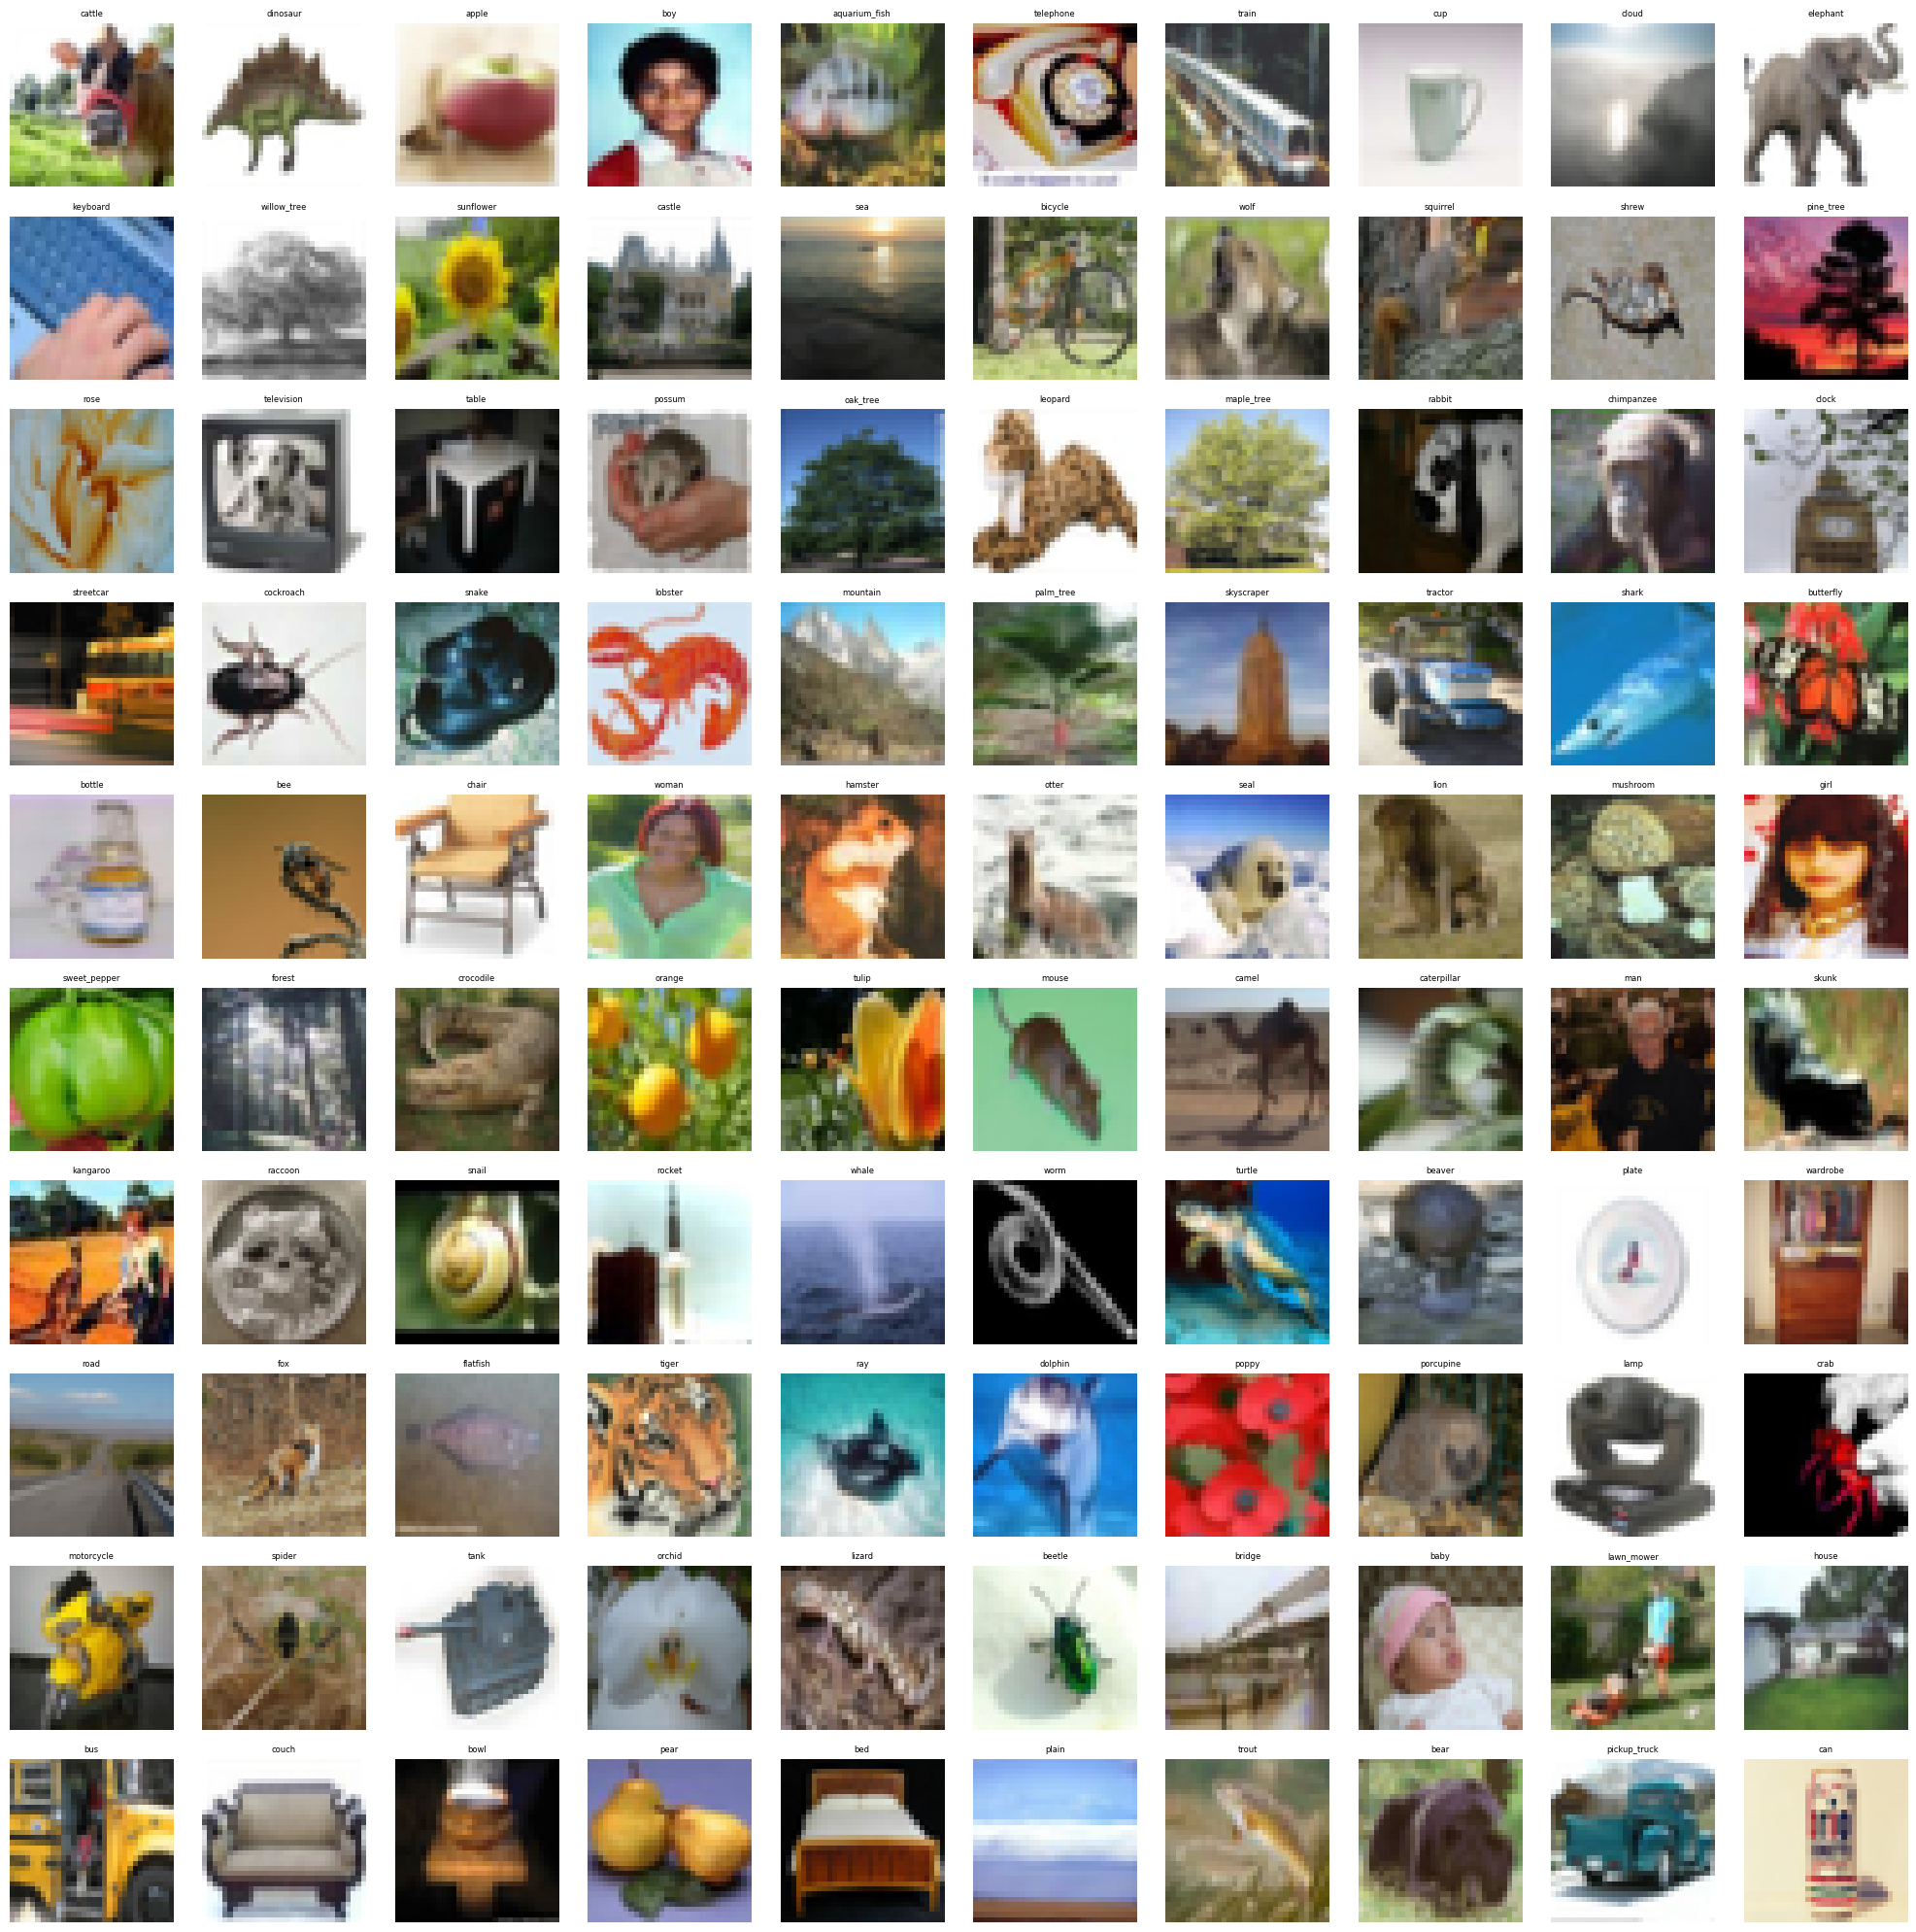

In [ ]:
show_one_image_per_class(X, y, classes)

k=1, Accuracy=0.0130
k=3, Accuracy=0.0090
k=5, Accuracy=0.0080
k=7, Accuracy=0.0110


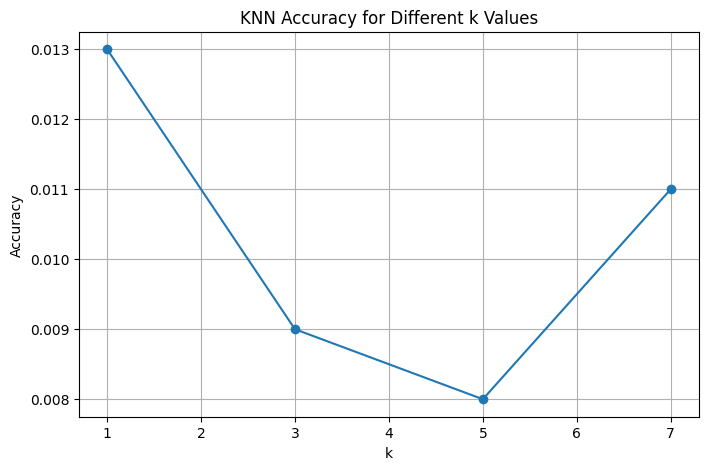

Best k: 1
Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 18:42:16


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Подготовка данных
X_flat = X.reshape(X.shape[0], -1) / 255.0  # flatten images + normalization

# Берём подвыборку, иначе KNN на 50k CIFAR может считаться очень долго
X_small = X_flat[:5000]
y_small = y[:5000]

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

k_values = [1, 3, 5, 7]
accuracies = []

for k in k_values:
    model = KnnClassifier(k=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"k={k}, Accuracy={acc:.4f}")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy for Different k Values')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Best k: {best_k}")
print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


#### Домашнее задание № 3

Задача предсказания цены бриллианта price

- Проверить наличие пропущенных значений, дубликатов, выбросов и шума в данных.
    - Провести полный разведочный анализ данных (EDA), включающий:
        - Анализ структуры и типов данных.
        - Подсчёт количества пропущенных значений и дубликатов.
        - Определение выбросов с помощью описательной статистики и визуальных методов
        - Проверку распределения признаков
        - Анализ категориальных признаков

- Определить, какие числовые признаки наиболее сильно коррелируют с целевой переменной.
    - Построить матрицу корреляций
    - Визуализировать её с помощью тепловой карты (heatmap)
- Разделить выборку на тренировочную и тестовую.
- Масштабировать данные.
- обучить модель с использованием KnnRegressor (задание № 1) и LinearRegression (sklearn)
- Визуализировать результат.
    - Построить графики предсказанных и истинных значений.
    - Построить диаграммы ошибок и метрики качества.
- Напишите выводы.



In [ ]:
data = pd.read_csv('data1.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB
None
Missing values:
 Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64
Duplicates: 0


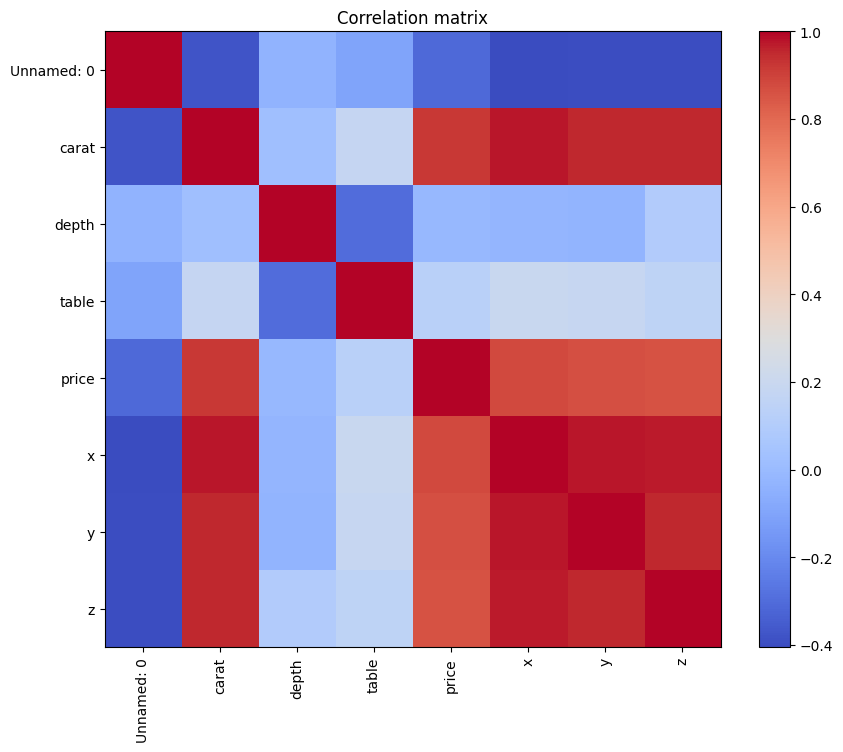

MSE: 1282237.9409818377
R2: 0.9193399796988827


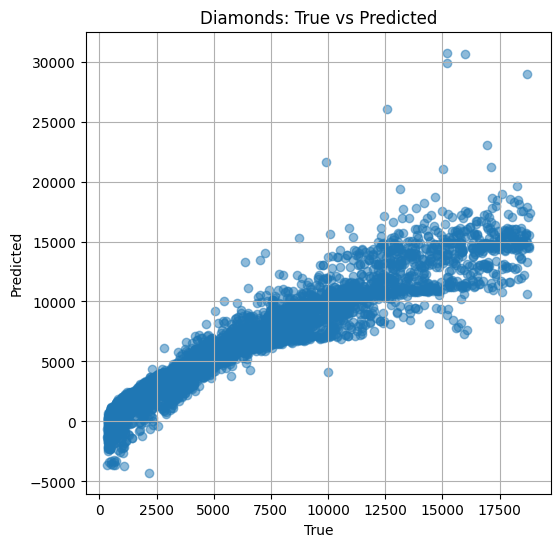

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 18:42:16


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print(data.info())
print("Missing values:\n", data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

numeric = data.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
plt.imshow(numeric.corr(), cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(numeric.columns)), numeric.columns, rotation=90)
plt.yticks(range(len(numeric.columns)), numeric.columns)
plt.title("Correlation matrix")
plt.show()

target='price'
X = pd.get_dummies(data.drop(columns=[target]), drop_first=True)
y = data[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

lr=LinearRegression()
lr.fit(X_train,y_train)
pred=lr.predict(X_test)

print("MSE:", mean_squared_error(y_test,pred))
print("R2:", r2_score(y_test,pred))

plt.figure(figsize=(6,6))
plt.scatter(y_test,pred,alpha=0.5)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Diamonds: True vs Predicted")
plt.grid(True)
plt.show()

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


#### Домашнее задание № 4
Задача для прогнозирования стоимости квартиры. Датасет содержит следующую информацию: количество комнат, общая площадь, жилая площадь, этаж, площадь кухни, расстояние от аэропорта, расстояние до центра города
1. Обучите модель на основе этих данных. Используйте метод градиентный спуск.
2. Посчитайте среднюю квадратичную ошибку и визуализируйте
3. Напишите выводы и интерпретируйте, как вы подбирали гиперпараметры

In [ ]:
data = np.loadtxt("data2.csv",delimiter=",", skiprows=1).T.tolist()

In [ ]:
print(np.isnan(theta).sum())
print(np.isnan(X_test).sum())
print(np.isnan(y_test).sum())



8
0
0


MSE: 70584493416673.52


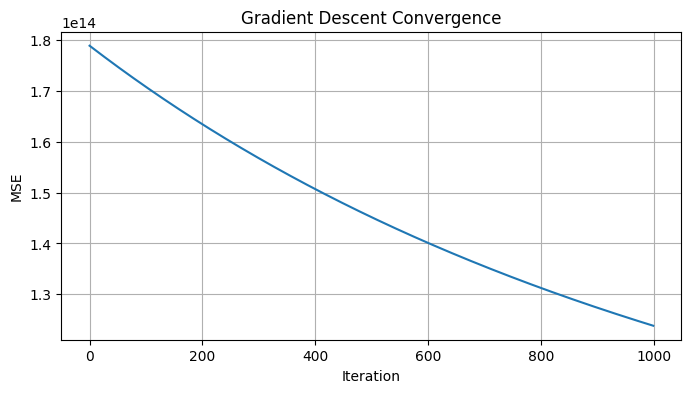

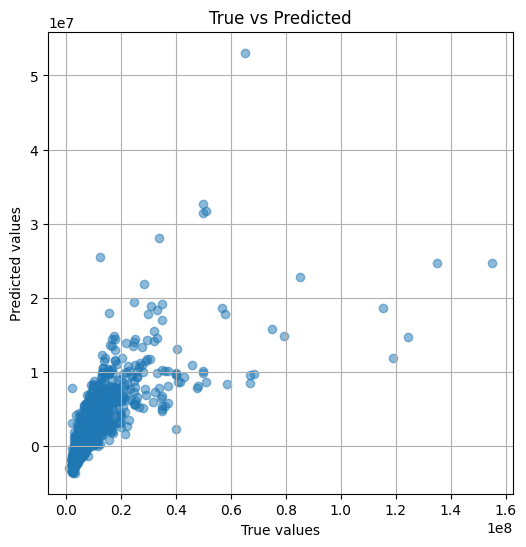

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 18:42:16


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data_np = np.array(data).T
X = data_np[:, :-1]
y = data_np[:, -1]

# normalize features FIRST
X = (X - X.mean(axis=0)) / X.std(axis=0)

# add bias AFTER normalization
X = np.c_[np.ones((X.shape[0], 1)), X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

theta = np.zeros(X_train.shape[1])
learning_rate = 0.0001
iterations = 1000
losses = []

for _ in range(iterations):
    preds = X_train.dot(theta)
    grad = (2 / len(X_train)) * X_train.T.dot(preds - y_train)
    theta -= learning_rate * grad
    losses.append(np.mean((preds - y_train) ** 2))

test_pred = X_test.dot(theta)
print("MSE:", mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Gradient Descent Convergence")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")
plt.grid(True)
plt.show()

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


In [ ]:
print(np.isnan(theta).sum())

0


np.isnan(theta).sum() = 8означает, что все 8 коэффициентов улетели в NaN во время gradient descent.
X_test и y_test чистые, значит данные не виноваты.То есть тут classic gradient descent moment: коэффициенты так разогнались, что превратились в математическую пыль. Нормализация + маленький шаг обычно быстро возвращают всё на землю.


#### Домашнее задание № 5
Следующий датасет содержит нелинейные данные. Нам необходимо найти оптимальную модель, чтобы прогнозировать с минимальными ошибками.
1. Используйте обычный градиентный спуск и визуализируйте результат.
2. Используйте полиномиальную регрессию и найдите необходимую степень полинома и визуализируйте результат.
3. Напишите выводы.

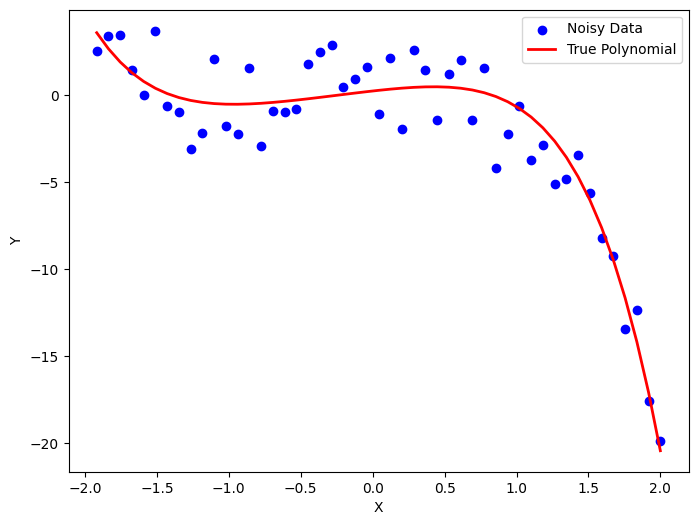

In [ ]:
data = np.loadtxt("data6.csv",delimiter=",", skiprows=1).T.tolist()
x=np.array(data[0])
y_noisy=np.array(data[1])
y_true=np.array(data[2])

plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, label='Noisy Data', color='blue')
plt.plot(x, y_true, label='True Polynomial', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

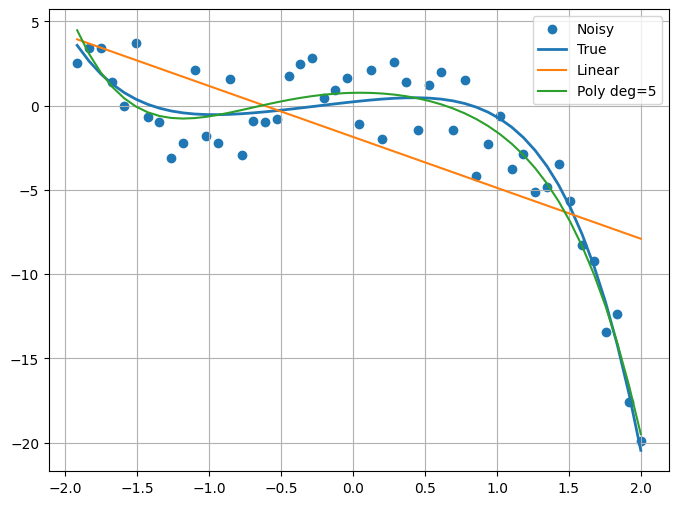

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 18:42:16


In [ ]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# linear
X_lin=x.reshape(-1,1)
lin=LinearRegression().fit(X_lin,y_noisy)
y_pred_lin=lin.predict(X_lin)

# polynomial
best_deg=5
poly_model=make_pipeline(PolynomialFeatures(best_deg), LinearRegression())
poly_model.fit(X_lin,y_noisy)
y_pred_poly=poly_model.predict(X_lin)

plt.figure(figsize=(8,6))
plt.scatter(x,y_noisy,label='Noisy')
plt.plot(x,y_true,label='True',linewidth=2)
plt.plot(x,y_pred_lin,label='Linear')
plt.plot(x,y_pred_poly,label='Poly deg=5')
plt.legend()
plt.grid(True)
plt.show()

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


### Домашнее задание № 6
На основе сгенерированных данных выполните следующие пункты:
1. Обучите модель
2. Визуализируйте траекторию градиентного спуска
3. Проверьте влияние размера шага на сходимость модели
    $\alpha = 0.0001$ , $\alpha = 0.01$ , $\alpha = 0.1$

4. Масштабируйте данные и проверьте сходимость модели
```python
X_new = X.copy()
X_new[:,1] = X_new[:,1] * 5
```
4. Напишите выводы.

In [ ]:
n_features = 2
n_objects = 300
num_steps = 100


np.random.seed(1)
w_true = np.random.normal(0, 0.1, size=(n_features, ))
w_0 = np.random.uniform(-2, 2, (n_features))

X = np.random.uniform(-5, 5, (n_objects, n_features))
y = np.dot(X, w_true) + np.random.normal(0, 1, (n_objects))

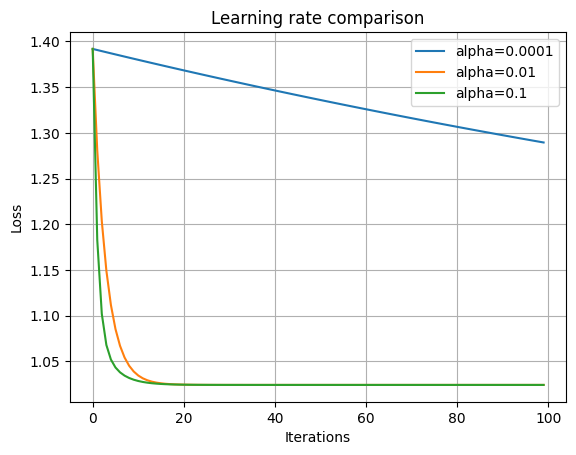

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 18:42:16


In [ ]:

def gd_run(X,y,alpha,steps):
    w=np.zeros(X.shape[1])
    losses=[]
    for _ in range(steps):
        pred=X.dot(w)
        grad=(2/len(X))*X.T.dot(pred-y)
        w-=alpha*grad
        losses.append(np.mean((pred-y)**2))
    return losses

for alpha in [0.0001,0.01,0.1]:
    losses=gd_run(X,y,alpha,num_steps)
    plt.plot(losses,label=f'alpha={alpha}')
plt.title('Learning rate comparison')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


### Домашнее задание № 7

#### Реализуйте полный градиентный спуск с матричными операциями

Градиент в матричной форме $$\nabla Q(\theta) = -2X^Ty + 2X^TX\theta = 2X^T(X\theta - y).$$

Сравните скорость работы обычного градиентного спуска и матричной формы



In [ ]:
n_features = 100
n_objects = 10000
num_steps = 2


np.random.seed(1)
w_true = np.random.normal(0, 0.1, size=(n_features, ))
w_0 = np.random.uniform(-2, 2, (n_features))

X = np.random.uniform(-5, 5, (n_objects, n_features))
y = np.dot(X, w_true) + np.random.normal(0, 1, (n_objects))

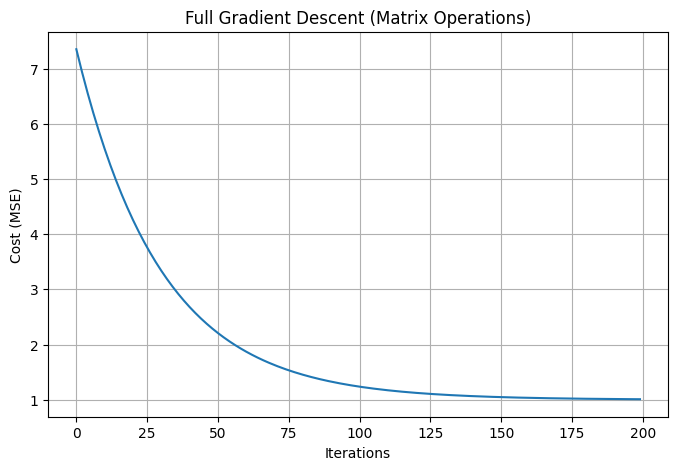

Matrix GD time: 0.36339688301086426
Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 18:42:16


In [ ]:

import time
m=X.shape[0]
X_b=np.c_[np.ones((m,1)),X]
theta=np.zeros(X_b.shape[1])
alpha=0.001
n_iterations=200
losses=[]

start=time.time()
y_col=y.reshape(-1,1)
theta=theta.reshape(-1,1)
for _ in range(n_iterations):
    gradients=(2/m)*X_b.T.dot(X_b.dot(theta)-y_col)
    theta-=alpha*gradients
    pred=X_b.dot(theta)
    losses.append(np.mean((pred-y_col)**2))
matrix_time=time.time()-start

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Full Gradient Descent (Matrix Operations)")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.grid(True)
plt.show()
print("Matrix GD time:", matrix_time)

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


### Домашнее задание № 8

Используйте датасет объявлений по продаже машин (), чтобы спрогнозировать стоимость машин. . Для дальнейшей работы сделайте следующее:

1. Проверить наличие пропущенных значений, дубликатов, выбросов и шума в данных.
    - Провести полный разведочный анализ данных (EDA), включающий:
        - Анализ структуры и типов данных.
        - Подсчёт количества пропущенных значений и дубликатов.
        - Определение выбросов с помощью описательной статистики и визуальных методов
        - Проверку распределения признаков
        - Анализ категориальных признаков

- Определить, какие числовые признаки наиболее сильно коррелируют с целевой переменной.
    - Построить матрицу корреляций
    - Визуализировать её с помощью тепловой карты (heatmap)

2. Разделите данные на обучающую и тестовую выборки

Сходимость стохастического градиентного спуска в зависимости от размера батча
```python
batch_sizes = np.arange(5, 500, 10)
```

3. Сделайте по несколько запусков  стохастического градиентного спуска на обучающей выборке для каждого размера батча из списка. Замерьте время и количество итераций до сходимости.

4. Постройте график зависимости количества шагов до сходимости от размера батча.
5. Постройте график зависимости времени до сходимости от размера батча.

6. Сравните для каждого метода результаты на тестовой выборке по метрикам MSE и $R^2$ с регуляризацией и без регуляризации. Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации.
4. Напишите выводы.

MSE: 26929599.646877714
R2: 0.591460568850612


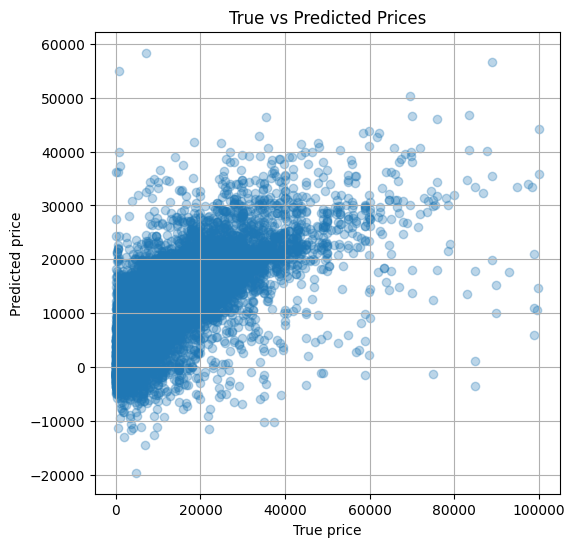

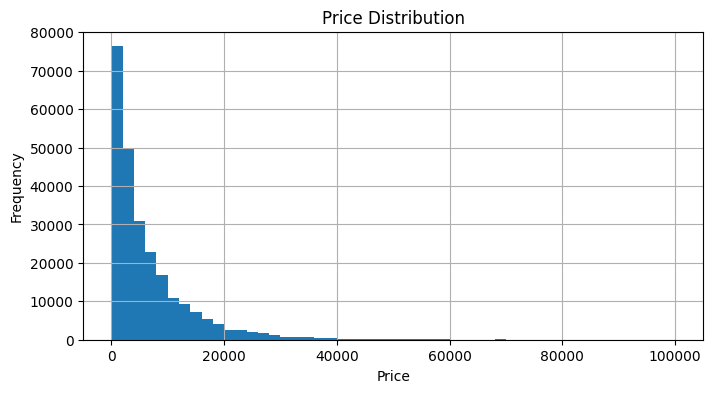

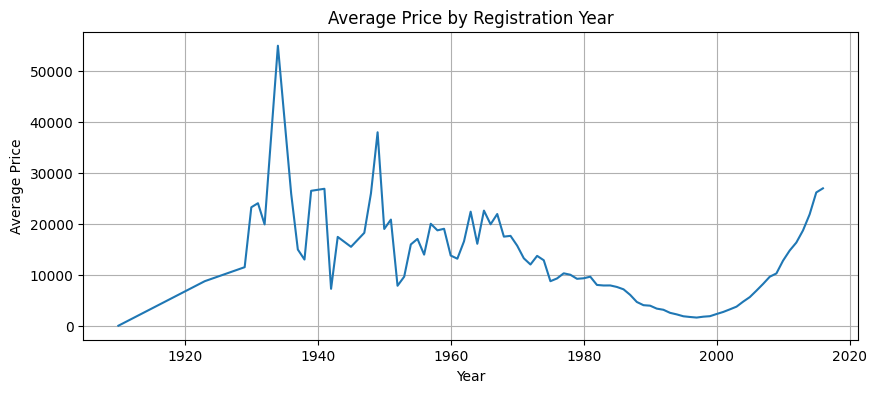

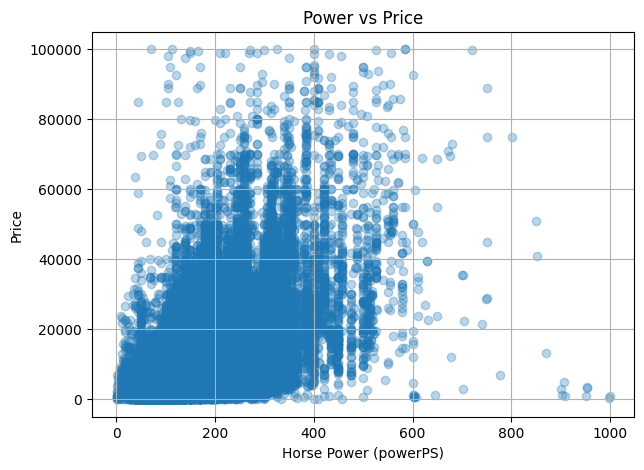

Name: Бададгулов Алексей Элгулджевич, Group: ЗПИбд01-24, StudentNumber: 1032231289, DateTime: 2026-05-14 19:06:28


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('autos.csv')

cols = ['powerPS', 'kilometer', 'yearOfRegistration',
        'monthOfRegistration', 'postalCode', 'price']

df_small = df[cols].dropna()

X = df_small.drop('price', axis=1)
y = df_small['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("True vs Predicted Prices")
plt.grid(True)
plt.show()

# Price distribution
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Average price by registration year
avg_price_by_year = df_small.groupby('yearOfRegistration')['price'].mean()

plt.figure(figsize=(10, 4))
plt.plot(avg_price_by_year.index, avg_price_by_year.values)
plt.title("Average Price by Registration Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

# Power vs Price
plt.figure(figsize=(7, 5))
plt.scatter(df_small['powerPS'], df_small['price'], alpha=0.3)
plt.title("Power vs Price")
plt.xlabel("Horse Power (powerPS)")
plt.ylabel("Price")
plt.grid(True)
plt.show()

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")
